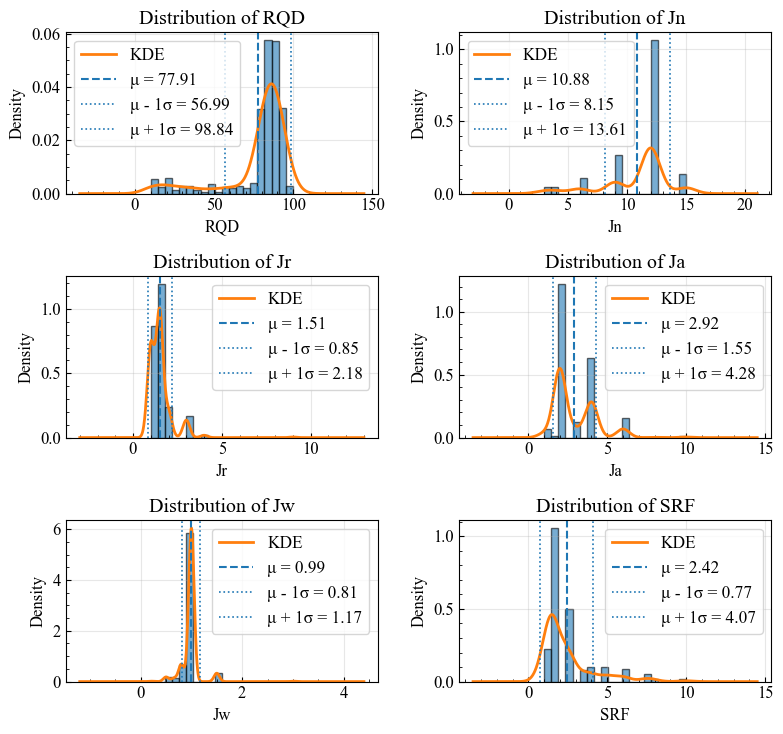

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["font.size"] = 12
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

data_path = "Q-RMR Data.xlsx"
sheet_idx = 0

df = pd.read_excel(data_path, sheet_name=sheet_idx)

feature_cols = ["RQD", "Jn", "Jr", "Ja", "Jw", "SRF"]

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")

plt.close("all")

fig, axes = plt.subplots(3, 2, figsize=(8, 7.5))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    x = X[col].dropna().values
    if x.size == 0:
        ax.set_title(f"{col} (no data)")
        ax.axis("off")
        continue

    mean = np.mean(x)
    std = np.std(x, ddof=1)

    ax.hist(
        x,
        bins=20,
        density=True,
        alpha=0.6,
        edgecolor="black",
    )

    pd.Series(x).plot(
        kind="kde",
        ax=ax,
        linewidth=2,
        label="KDE"
    )

    ax.axvline(mean, linestyle="--", linewidth=1.5, label=f"μ = {mean:.2f}")
    ax.axvline(mean - std, linestyle=":", linewidth=1.2, label=f"μ - 1σ = {mean - std:.2f}")
    ax.axvline(mean + std, linestyle=":", linewidth=1.2, label=f"μ + 1σ = {mean + std:.2f}")

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

    ax.minorticks_on()
    ax.tick_params(axis="both", which="both", direction="in")

    ax.grid(alpha=0.3)
    ax.legend(fontsize=12.5)

for i in range(len(feature_cols), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()